In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive
from importlib import reload
drive.mount('/content/drive')

path = '/content/drive/MyDrive/_TRABALHO_PESQUISAS/TRABALHO_PESQUISA_ARTIGOS_FINALIZAR/08_COMPARATIVO_GPS_CELULAR'
df_init = pd.read_excel( path+'/STAT/PONTOS_COM_COORDENADAS.xlsx')
#CRIANDO LISTAS DAS COLUNAS DE ERRO XY E ERRO LINEAR
list_erroXY = df_init.columns.values.tolist()[10:16:]
list_erroLin = df_init.columns.values.tolist()[16::]
list_label = ['iOS', 'Android', 'GARMIN']

Mounted at /content/drive


In [ ]:
#mostrando as primeiras linhas de um grupo de colunas
#df_init[list_erroXY].head()

## ESTATISTICA DESCRITIVA DOS ERROS ##
#df_init[list_erroXY].describe()
#df_init[list_erroLin].describe()
df_stat = df_init[list_erroXY+list_erroLin].describe()
df_stat.to_excel(path+'/STAT/STAT_ERROS_.xlsx')
#


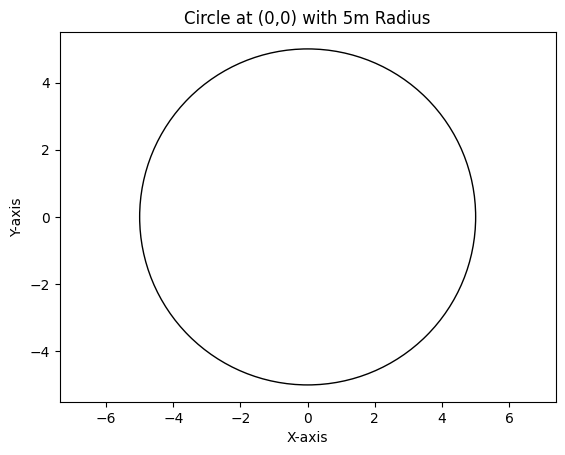

In [ ]:
# prompt: em um gráfico do matplolib como faço para adicionar um circulo na coordenada central 0,0, com 5 metros de raio, com linha externa na cor preta, e sem preenchimento?, gere uma figura com mesma dimensão em X e em Y. a linha do cpirculo deve ser cinza tracejado

import matplotlib.pyplot as plt
import numpy as np

# Create a figure and axes with equal aspect ratio
fig, ax = plt.subplots(figsize=(6, 6))  # Adjust figsize as needed
ax.set_aspect('equal')

# Set the radius of the circle
radius = 5

# Create the circle using a circle patch
circle = plt.Circle((0, 0), radius, fill=False, edgecolor='gray', linestyle='dashed', linewidth=1) # Adjust linewidth if needed


# Add the circle to the axes
ax.add_patch(circle)

# Set the limits of the plot
ax.set_xlim([-radius * 1.2, radius * 1.2])  # Add a little padding around the circle
ax.set_ylim([-radius * 1.2, radius * 1.2])


# Add grid lines for better visualization
ax.grid(True, linestyle='--', alpha=0.5)

# Add labels and title
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_title("Circle with 5 meters radius at (0, 0)")

plt.show()

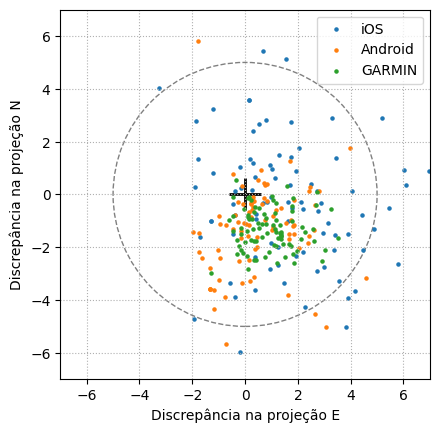

[-7, 7]

In [ ]:
## GRÁFICOS DE DISPERSÃO ##
reload(plt)
#configurações de símbolo e tamanho de síimbolo do gráfico
simbolo = 'o'
tamanho = 5
#dados para o gráfico
fig, ax = plt.subplots()
#plt.figure(figsize=(6,6))
plt.scatter(0,0,s=500,color='black', marker = '+', lw=2)

circle = plt.Circle((0, 0), 5,fill=False, edgecolor='gray', linestyle='dashed', linewidth=1)
ax.add_patch(circle)
plt.scatter(df_init['ERRO_IPHONE_X'], df_init['ERRO_IPHONE_Y'], label = 'iOS', marker=simbolo, s=tamanho)
plt.scatter(df_init['ERRO_ANDROID_X'], df_init['ERRO_ANDROID_Y'], label = 'Android',marker=simbolo, s=tamanho)
plt.scatter(df_init['ERRO_GARMIN_X'], df_init['ERRO_GARMIN_Y'], label = 'GARMIN', marker=simbolo, s=tamanho)

#configurações do gráfico
plt.legend()
plt.grid(True, linestyle = ':',)
#mesma proporção entre X e Y
#plt.axis('equal')
ax.set_aspect('equal', adjustable='box')
#limites máximos e mínimos do gráfico, para o valor 0,0 ficar centralizado
XY_max_error = df_init[list_erroXY].abs().values.max()
lim_graph = int(XY_max_error)
list_lim_graph = [lim_graph*-1, lim_graph]
plt.ylim(list_lim_graph)
plt.xlim(list_lim_graph)
plt.xlabel('Discrepância na projeção E',loc='center')
plt.ylabel('Discrepância na projeção N')
plt.show()
list_lim_graph

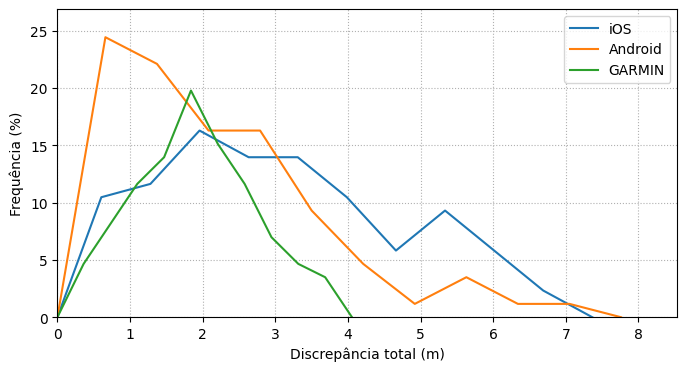

In [ ]:
### GRÁFICO DE DISTRIBUIÇÃO DE FREQUÊNCIA ###
reload(plt)
bins = 10

def CalcHistLin(data, nbins):
    count, bins_values = np.histogram(data, bins=nbins)
    total_count = sum(count)
    percent_value = (count/total_count)*100
    bins_center=0.5*(bins_values[:-1]+bins_values[1:])
    #inserindo 0,0
    bins_center = np.insert(bins_center, 0, 0)
    bins_center = np.append(bins_center,(2*bins_center[-1]-bins_center[-2]))
    percent_value = np.insert(percent_value, 0, 0)
    percent_value = np.append(percent_value, 0)
    return bins_center, percent_value

bin_center_iOS, percent_iOS = CalcHistLin(df_init['ERRO_IPHONE_TOT'], bins)
bin_centr_Android, percent_Android = CalcHistLin(df_init['ERRO_ANDROID_TOT'], bins)
bin_center_GARMIN, percent_GARMIN = CalcHistLin(df_init['ERRO_GARMIN_TOT'], bins)

plt.figure(figsize=(8,4))
plt.plot(bin_center_iOS, percent_iOS, label='iOS')
plt.plot(bin_centr_Android, percent_Android, label='Android')
plt.plot(bin_center_GARMIN, percent_GARMIN, label='GARMIN')
plt.xlabel('Discrepância total (m)',loc='center')
plt.ylabel('Frequência (%)')
plt.ylim(0,max(np.concatenate((percent_iOS,percent_GARMIN,percent_Android))*1.1))
plt.xlim(0,max(np.concatenate((bin_center_iOS,bin_centr_Android,bin_center_GARMIN))*1.1))
plt.grid(True, linestyle = ':')
plt.legend()
plt.show()


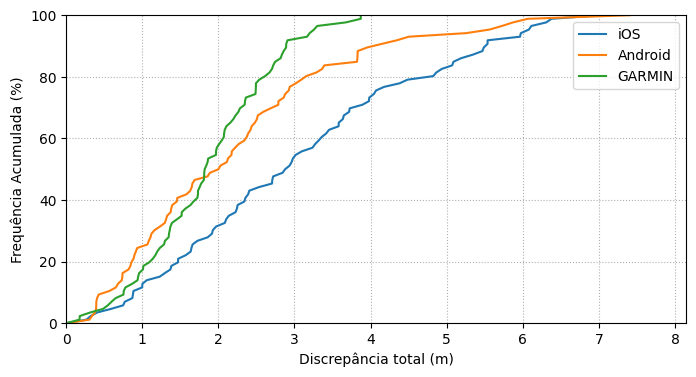

In [ ]:
reload(plt)
def CalcAcumFreq(data):
  data_sort = np.sort(data.to_list())
  cumulative_count = np.arange(1,len(data_sort)+1)
  cumulative_percentage = (cumulative_count / len(data_sort)) * 100
  data_sort = np.insert(data_sort, 0, 0)
  cumulative_percentage = np.insert(cumulative_percentage, 0, 0)
  return data_sort, cumulative_percentage

data_sort_iOS, cumulative_percentage_iOS = CalcAcumFreq(df_init['ERRO_IPHONE_TOT'])
data_sort_Android, cumulative_percentage_Android = CalcAcumFreq(df_init['ERRO_ANDROID_TOT'])
data_sort_GARMIN, cumulative_percentage_GARMIN = CalcAcumFreq(df_init['ERRO_GARMIN_TOT'])

plt.figure(figsize=(8,4))
plt.plot(data_sort_iOS, cumulative_percentage_iOS, label='iOS')
plt.plot(data_sort_Android, cumulative_percentage_Android, label='Android')
plt.plot(data_sort_GARMIN, cumulative_percentage_GARMIN, label='GARMIN')
plt.xlabel('Discrepância total (m)',loc='center')
plt.ylabel('Frequência Acumulada (%)')

plt.ylim(0,100)
plt.xlim(0,max(np.concatenate((data_sort_iOS,data_sort_Android,data_sort_GARMIN))*1.1))
plt.grid(True, linestyle = ':')
plt.legend()
plt.show()



In [ ]:
list_erroLin

['ERRO_IPHONE_TOT', 'ERRO_ANDROID_TOT', 'ERRO_GARMIN_TOT']

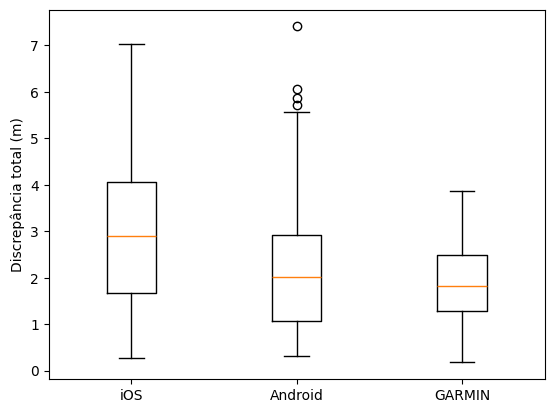

In [ ]:
reload(plt)

plt.boxplot(df_init[list_erroLin], labels=list_label)
plt.ylabel('Discrepância total (m)')
plt.show()

In [ ]:
### PEC-PCD ###
from  math import ceil
#90% dos dados
print('CALCULANDO ERRO A 90% DOS DADOS')
for item in list_erroLin:
  #Perc90_Pos = int(len(df_init[list_erroLin[item]])*0.9)
  Perc90_Pos = int(len(df_init[item])*0.9)
  errolin_sort = np.sort(df_init[item])
  print(item, errolin_sort[Perc90_Pos])

#Perc90_Pos = int(len(df_init[list_erroLin[0]])*0.9)
#errolin_sort = np.sort(df_init[list_erroLin[0]])
#print(Perc90_Pos)
print('.')

#eqm
print('CALCULANDO EQM')
def EQM(erros:list):
  return (sum(erros**2)/len(erros))**0.5

for item in list_erroLin:
  print(item, EQM(df_init[item]))

CALCULANDO ERRO A 90% DOS DADOS
ERRO_IPHONE_TOT 5.536246257399633
ERRO_ANDROID_TOT 4.148230249416882
ERRO_GARMIN_TOT 2.8912432613791648
.
CALCULANDO EQM
ERRO_IPHONE_TOT 3.4875389853881584
ERRO_ANDROID_TOT 2.6633489761183466
ERRO_GARMIN_TOT 2.0518524114199703


In [ ]:
len(list_erroLin[0])

15

In [ ]:
array1 = np.array([1,2,3,4,5,6,7,8,9,10])
(sum(array1**2)/len(array1))**0.5

6.2048368229954285

In [ ]:
# prompt: como juntar três arrays?

import numpy as np

# Example arrays
array1 = np.array([1, 2, 3])
array2 = np.array([4, 5, 6])
array3 = np.array([7, 8, 9])

# Method 1: Using concatenate
concatenated_array = np.concatenate((array1, array2, array3))
print("Concatenated array:", concatenated_array)

# Method 2: Using hstack (horizontal stack)
hstacked_array = np.hstack((array1, array2, array3))
print("Horizontally stacked array:", hstacked_array)

# Method 3: Using vstack (vertical stack) -  creates a 2D array
vstacked_array = np.vstack((array1, array2, array3))
print("Vertically stacked array:\n", vstacked_array)


#Method 4: Using append repeatedly
appended_array = array1
appended_array = np.append(appended_array, array2)
appended_array = np.append(appended_array, array3)

print("Appended Array:", appended_array)

#For your specific case (assuming you want to combine the erro_tot columns)
# Assuming df_init is your dataframe as in your original code

# Create a new column combining the values.
# You might need to handle NaN or missing values depending on your data
df_init['ERRO_TOTAL_ALL'] = df_init['ERRO_IPHONE_TOT'].fillna(0) + df_init['ERRO_ANDROID_TOT'].fillna(0) + df_init['ERRO_GARMIN_TOT'].fillna(0)

#To see the new column
print(df_init[['ERRO_IPHONE_TOT', 'ERRO_ANDROID_TOT', 'ERRO_GARMIN_TOT', 'ERRO_TOTAL_ALL']])


#Convert the combined error column to a NumPy array:
erro_total_all_array = df_init['ERRO_TOTAL_ALL'].to_numpy()

erro_total_all_array